# Project environment test

Select **Python (gene-complexity)** as the kernel, then run all cells in order.
See the README for virtual-environment setup and the dataset download link.
This notebook checks the active Python environment and required imports, then previews the local Pancreas dataset without changing it.


In [1]:
import sys
from pathlib import Path

# Find the repository even if Jupyter was started in a subdirectory.
project_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "requirements.txt").is_file()
     and (path / "environment_test.ipynb").is_file()),
    None,
)
assert project_root is not None, "Start Jupyter from the gene-complexity repository."
expected_venv = (project_root / ".venv").resolve()
print("Python version:", sys.version.split()[0])
print("Python executable:", sys.executable)
print("Environment prefix:", sys.prefix)
print("Expected environment:", expected_venv)
assert sys.prefix != sys.base_prefix, "The kernel is not running in a virtual environment. Select Python (gene-complexity)."
assert Path(sys.prefix).resolve() == expected_venv, "The kernel is using a different environment. Select Python (gene-complexity)."
print("PASS: the kernel is running in this project's .venv.")


Python version: 3.14.6
Python executable: /Users/jonathanma/Desktop/Projects/gene-complexity/.venv/bin/python
Environment prefix: /Users/jonathanma/Desktop/Projects/gene-complexity/.venv
Expected environment: /Users/jonathanma/Desktop/Projects/gene-complexity/.venv
PASS: the kernel is running in this project's .venv.


## Check every project dependency

Import each package listed in `requirements.txt` and show its installed version. Import failures are collected so that all problematic packages are reported together.


In [2]:
import importlib
from importlib.metadata import version
import re

# Distribution names and Python import names can differ.
import_names = {"torch": "torch", "numpy": "numpy", "pandas": "pandas",
                "matplotlib": "matplotlib", "notebook": "notebook", "anndata": "anndata", "scikit-learn": "sklearn"}
failures = []
for line in (project_root / "requirements.txt").read_text().splitlines():
    requirement = line.split("#", 1)[0].strip()
    if not requirement:
        continue
    package = re.split(r"[<>=!~;\[\s]", requirement, maxsplit=1)[0]
    try:
        importlib.import_module(import_names.get(package, package.replace("-", "_")))
        print(f"PASS: {package} {version(package)}")
    except Exception as exc:
        failures.append(f"{package}: {type(exc).__name__}: {exc}")
        print(f"FAIL: {failures[-1]}")
assert not failures, "Fix these imports using the README setup instructions, then restart the kernel:\n" + "\n".join(failures)
print("All project dependencies imported successfully.")


PASS: torch 2.14.1
PASS: numpy 2.5.3
PASS: pandas 3.0.6
PASS: matplotlib 3.11.2
PASS: notebook 7.6.3
PASS: anndata 0.13.4
All project dependencies imported successfully.


In [3]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

# Small numerical checks exercise NumPy and PyTorch on CPU.
values = np.array([1.0, 2.0, 3.0], dtype=np.float32)
assert np.isclose(values.mean(), 2.0)
assert torch.isclose(torch.from_numpy(values).mean(), torch.tensor(2.0)).item()
print("PASS: NumPy and PyTorch numerical checks.")
print("CUDA available:", torch.cuda.is_available())
print("Apple MPS available:", torch.backends.mps.is_available())
print("GPU acceleration is optional for this environment test.")


PASS: NumPy and PyTorch numerical checks.
CUDA available: False
Apple MPS available: True
GPU acceleration is optional for this environment test.


## Load and display the Pancreas data

Download `pancreas.h5ad` to `data/raw/` using the README instructions before running this cell. In AnnData, rows represent cells, columns represent genes, and `obs` contains cell metadata. Only a small expression slice is converted to a dense table.


In [4]:
data_path = project_root / "data" / "raw" / "pancreas.h5ad"
if not data_path.is_file():
    raise FileNotFoundError(
        f"Dataset not found: {data_path}\n"
        "Download https://exampledata.scverse.org/scvi-tools/pancreas.h5ad "
        "to data/raw/pancreas.h5ad (see README)."
    )
adata = ad.read_h5ad(data_path)
print(adata)
assert adata.n_obs > 0 and adata.n_vars > 0, "The dataset is empty."
assert {"celltype", "tech"}.issubset(adata.obs.columns), "Expected celltype and tech metadata are missing."
assert "counts" in adata.layers, "Expected counts layer is missing."
print(f"Cells: {adata.n_obs:,}; genes: {adata.n_vars:,}")
print("Cell metadata (first five cells):")
display(adata.obs.head())
print("Gene metadata (first five genes):")
display(adata.var.head())

preview = adata.layers["counts"][:5, :10]
if hasattr(preview, "toarray"):
    preview = preview.toarray()
print("Counts layer (first five cells and ten genes):")
display(pd.DataFrame(np.asarray(preview), index=adata.obs_names[:5], columns=adata.var_names[:10]))


AnnData object with n_obs × n_vars = 16382 × 19093
    obs: 'tech', 'celltype', 'size_factors'
    layers: 'counts', None (.X)
Cells: 16,382; genes: 19,093
Cell metadata (first five cells):


,tech,celltype,size_factors
D101_5,celseq,gamma,0.028492
D101_43,celseq,gamma,0.079348
D101_93,celseq,gamma,0.037932
D102_4,celseq,gamma,0.047685
D172444_23,celseq,gamma,0.038683


Gene metadata (first five genes):


""
A1BG
A1CF
A2M
A2ML1
A4GALT


Counts layer (first five cells and ten genes):


,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AA06,AAAS,AACS,AACSP1
D101_5,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
D101_43,1.001958,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
D101_93,0.000000,1.001958,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
D102_4,1.001958,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,1.001958,0.0
D172444_23,0.000000,1.001958,0.0,1.001958,0.0,0.0,0.0,0.0,0.000000,0.0


Cells per cell type:


,n_cells
celltype,
alpha,5493
beta,4169
ductal,2142
acinar,1669
delta,1055
gamma,699
activated_stellate,464
endothelial,313
quiescent_stellate,193


Cells per sequencing technology:


,n_cells
tech,
inDrop3,3605
smartseq2,2394
celseq2,2285
inDrop1,1937
inDrop2,1724
smarter,1492
inDrop4,1303
celseq,1004
fluidigmc1,638


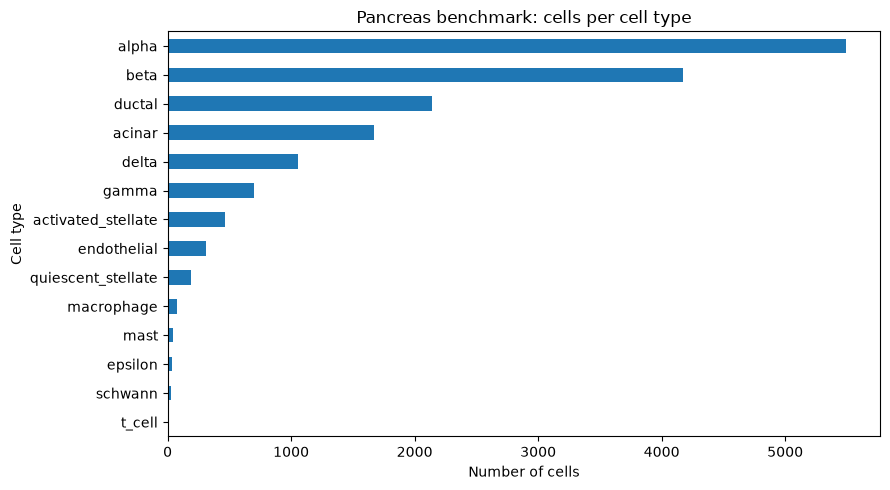

PASS: environment checks and dataset preview completed.


In [5]:
cell_counts = adata.obs["celltype"].value_counts()
print("Cells per cell type:")
display(cell_counts.rename("n_cells").to_frame())
print("Cells per sequencing technology:")
display(adata.obs["tech"].value_counts().rename("n_cells").to_frame())

fig, ax = plt.subplots(figsize=(9, 5))
cell_counts.sort_values().plot.barh(ax=ax)
ax.set(title="Pancreas benchmark: cells per cell type", xlabel="Number of cells", ylabel="Cell type")
fig.tight_layout()
plt.show()
print("PASS: environment checks and dataset preview completed.")
